# 🩺 Pelatihan Model Segmentasi U-Net Lesi Kulit (Google Colab)

**Tujuan:** Melatih model segmentasi U-Net menggunakan masker lesi HAM10000 (Tschandl et al., Nature Medicine 2020) dengan protokol **Zero Data Leakage**.
* **Strategi Anti-Bocor:** U-Net hanya dilatih dari partisi `train` dan divalidasi pada partisi `val`. Partisi `test` 100% diisolasi.
* **Arsitektur:** U-Net dengan Encoder ResNet-34 (Pre-trained ImageNet) & kombinasi fungsi loss medis $\mathcal{L} = \text{BCE} + (1 - \text{Dice})$.
* **Penyimpanan:** Bobot model terbaik (`best_unet_ham10k.pth`), kurva metrik, dan sampel prediksi disimpan langsung ke Google Drive.

In [1]:
# 1. Hubungkan ke Google Drive
import os
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

# Folder penyimpanan hasil di Google Drive
OUTPUT_DIR = Path('/content/drive/MyDrive/riset_kulit_segmentasi')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Folder output Google Drive siap: {OUTPUT_DIR}")

Mounted at /content/drive
Folder output Google Drive siap: /content/drive/MyDrive/riset_kulit_segmentasi


In [2]:
# 2. Instalasi library dan verifikasi GPU
!pip install -q segmentation-models-pytorch albumentations kagglehub

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device aktif: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.9 MB/s eta 0:00:00
Device aktif: cuda
GPU Name: NVIDIA A100-SXM4-40GB
VRAM: 39.49 GB


In [3]:
# 3. Pemuatan dataset dari Kaggle (Otomatis via KaggleHub)
import kagglehub

# print("Mengunduh dataset citra HAM10000...")
# path_images = kagglehub.dataset_download("nadiraanindita/dataset-riset-ham10k")

print("Mengunduh dataset masker HAM10000...")
path_masks = kagglehub.dataset_download("nadiraanindita/ham-segmentations-lesion-riset-saya")

print("Mengunduh metadata partisi (split train/val/test)...")
path_split = kagglehub.dataset_download("nadiraanindita/ham10k-and-isic-2019")

DIR_IMAGES = Path(path_images)
DIR_MASKS = Path(path_masks)
DIR_SPLIT = Path(path_split)

print(f"Direktori Images: {DIR_IMAGES}")
print(f"Direktori Masks : {DIR_MASKS}")
print(f"Direktori Split : {DIR_SPLIT}")

Mengunduh dataset masker HAM10000...


100%|██████████| 10.3M/10.3M [00:00<00:00, 124MB/s]

Extracting files...


Mengunduh metadata partisi (split train/val/test)...


100%|██████████| 4.70M/4.70M [00:00<00:00, 128MB/s]

Extracting files...


NameError: name 'path_images' is not defined

In [4]:
# 4. Audit & Matching Image ID <-> Mask ID (Zero Data Leakage Protocol)
import re
import pandas as pd

# Helper pembaca CSV aman multi-encoding
def safe_read_csv(fpath):
    for enc in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
        try:
            return pd.read_csv(fpath, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(fpath, encoding_errors='replace')

# Temukan file CSV split di direktori split
csv_files = list(DIR_SPLIT.glob('**/*.csv'))
print(f"File CSV ditemukan: {[f.name for f in csv_files]}")

# Prioritas 1: Gunakan split_assignments.csv jika tersedia
split_file = None
for f in csv_files:
    if f.name == 'split_assignments.csv':
        split_file = f
        break

if split_file:
    df_meta = safe_read_csv(split_file)
    print(f"Menggunakan file master split: {split_file.name} ({len(df_meta):,} baris)")
else:
    # Prioritas 2: Muat train.csv, val.csv, test.csv
    dfs = []
    for f in csv_files:
        if f.name in ['train.csv', 'val.csv', 'test.csv']:
            df_temp = safe_read_csv(f)
            if 'split' not in df_temp.columns:
                df_temp['split'] = f.stem
            dfs.append(df_temp)
    if dfs:
        df_meta = pd.concat(dfs, ignore_index=True)
    else:
        df_meta = pd.concat([safe_read_csv(f) for f in csv_files], ignore_index=True)

# Standarisasi nama kolom image_id
for col in ['image', 'isic_id', 'Image', 'IMAGE']:
    if col in df_meta.columns and 'image_id' not in df_meta.columns:
        df_meta = df_meta.rename(columns={col: 'image_id'})

df_meta = df_meta.drop_duplicates(subset=['image_id'])
print(f"Total metadata citra termuat: {len(df_meta):,} baris unik")

# Indeks seluruh path file fisik citra (.jpg)
all_images = {}
for p in DIR_IMAGES.glob('**/*.jpg'):
    all_images[p.stem] = str(p)

# Indeks seluruh path file fisik masker (.png)
all_masks = {}
for p in DIR_MASKS.glob('**/*.png'):
    clean_id = re.sub(r'_segmentation$', '', p.stem)
    all_masks[clean_id] = str(p)

print(f"Total citra fisik ditemukan : {len(all_images):,}")
print(f"Total masker fisik ditemukan: {len(all_masks):,}")

# Filter hanya baris yang memiliki pasangan citra & masker lengkap
matched_records = []
for _, row in df_meta.iterrows():
    img_id = str(row['image_id']).strip()
    split_val = str(row.get('split', '')).strip().lower()

    if img_id in all_images and img_id in all_masks:
        matched_records.append({
            'image_id': img_id,
            'image_path': all_images[img_id],
            'mask_path': all_masks[img_id],
            'split': split_val
        })

df_matched = pd.DataFrame(matched_records)
print(f"Total citra berpasangan masker: {len(df_matched):,}")

# Filter ketat: HANYA train dan val yang masuk ke U-Net (Test 100% diisolasi)
train_df = df_matched[df_matched['split'] == 'train'].reset_index(drop=True)
val_df = df_matched[df_matched['split'] == 'val'].reset_index(drop=True)
test_df = df_matched[df_matched['split'] == 'test'].reset_index(drop=True)

print("\n=== HASIL PARTISI ZERO-LEAKAGE U-NET ===")
print(f"Train Set (Dipakai U-Net Latih)   : {len(train_df):,} citra")
print(f"Val Set   (Dipakai U-Net Evaluasi): {len(val_df):,} citra")
print(f"Test Set  (DIISOLASI TOTAL)       : {len(test_df):,} citra (0% bocor)")

assert len(train_df) > 0, "Data train kosong! Periksa format kolom 'split' di CSV."
assert len(val_df) > 0, "Data val kosong! Periksa format kolom 'split' di CSV."

File CSV ditemukan: ['train.csv', 'train_3class.csv', 'test.csv', 'val.csv', 'test_3class.csv', 'val_3class.csv', 'split_assignments.csv']
Menggunakan file master split: split_assignments.csv (31,477 baris)
Total metadata citra termuat: 31,477 baris unik
Total citra fisik ditemukan : 11,526
Total masker fisik ditemukan: 10,015
Total citra berpasangan masker: 10,013

=== HASIL PARTISI ZERO-LEAKAGE U-NET ===
Train Set (Dipakai U-Net Latih)   : 8,007 citra
Val Set   (Dipakai U-Net Evaluasi): 981 citra
Test Set  (DIISOLASI TOTAL)       : 1,025 citra (0% bocor)


In [5]:
# 5. PyTorch Dataset & Pipeline Augmentasi
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class SkinLesionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)  # Biner [0.0, 1.0]

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask'].unsqueeze(0)

        return img, mask, row['image_id']

train_ds = SkinLesionDataset(train_df, transform=train_transforms)
val_ds = SkinLesionDataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"DataLoader siap: {len(train_loader)} batch latih, {len(val_loader)} batch validasi.")

DataLoader siap: 251 batch latih, 31 batch validasi.


/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [12]:
print("5 Contoh File Citra :", [p.name for p in list(DIR_IMAGES.glob('**/*.jpg'))[:5]])
print("5 Contoh File Masker:", [p.name for p in list(DIR_MASKS.glob('**/*.png'))[:5]])

5 Contoh File Citra : ['ISIC_0027398.jpg', 'ISIC_0027029.jpg', 'ISIC_0025722.jpg', 'ISIC_0024317.jpg', 'ISIC_0027937.jpg']
5 Contoh File Masker: ['ISIC_0029188_segmentation.png', 'ISIC_0030820_segmentation.png', 'ISIC_0025694_segmentation.png', 'ISIC_0033233_segmentation.png', 'ISIC_0028594_segmentation.png']


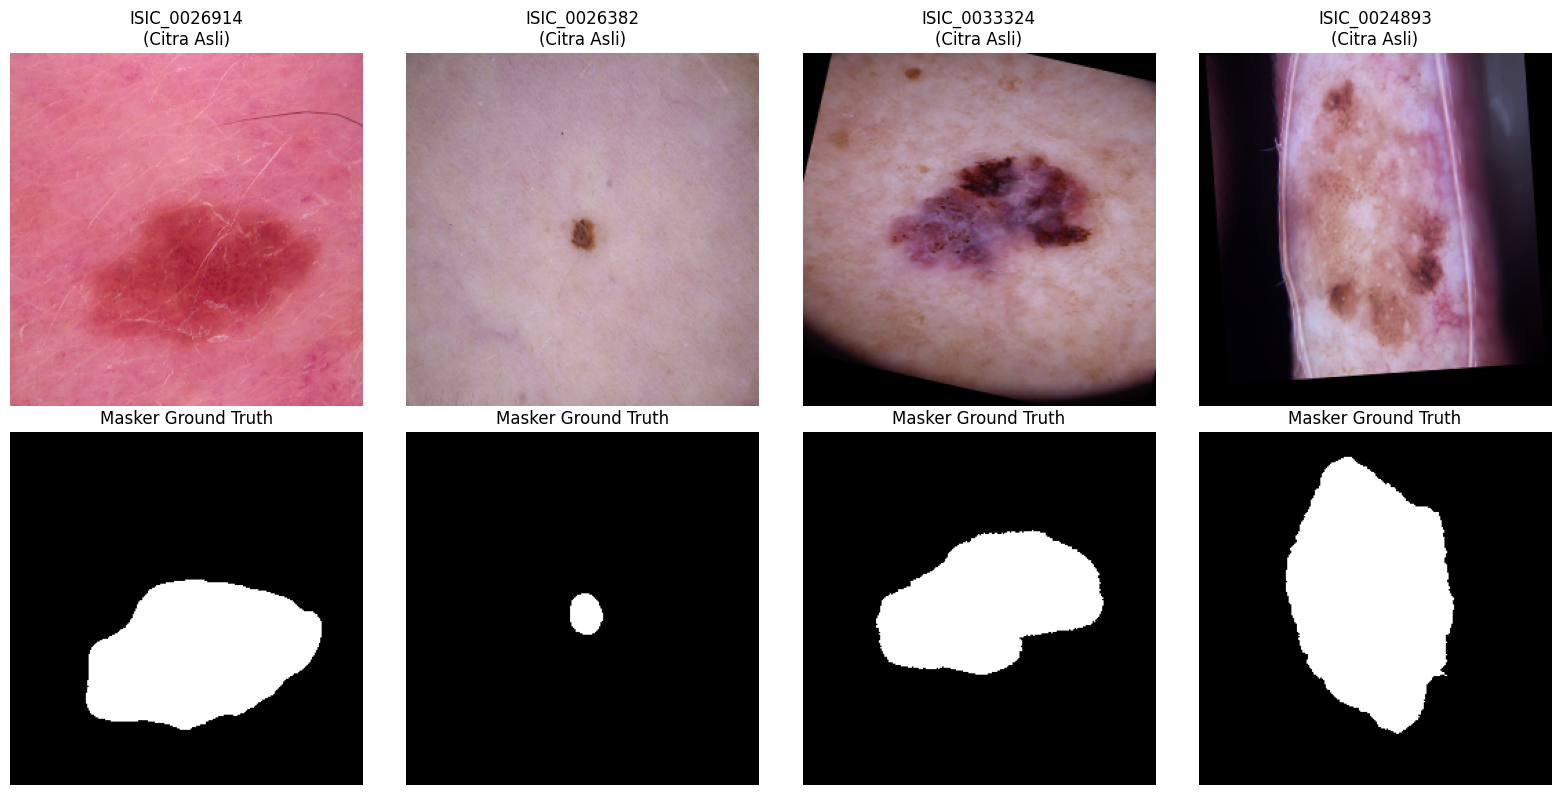

In [6]:
# 6. Sanity check: Visualisasi sampel citra & masker ground truth
import matplotlib.pyplot as plt

sample_imgs, sample_masks, sample_ids = next(iter(train_loader))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_np = sample_imgs[i].permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)
    mask_np = sample_masks[i, 0].cpu().numpy()

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"{sample_ids[i]}\n(Citra Asli)")
    axes[0, i].axis('off')

    axes[1, i].imshow(mask_np, cmap='gray')
    axes[1, i].set_title("Masker Ground Truth")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# 7. Arsitektur U-Net ResNet-34 & Loss Medis (BCE + Dice)
import torch.nn as nn
import segmentation_models_pytorch as smp

# Inisialisasi U-Net dengan backbone ResNet-34 pre-trained
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)

class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, pred_logits, targets):
        bce_loss = self.bce(pred_logits, targets)
        probs = torch.sigmoid(pred_logits)

        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)

        intersection = (probs_flat * targets_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1.0 - dice_score

        return bce_loss + dice_loss

criterion = BCEDiceLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
print("Model U-Net ResNet-34 & Loss Medis berhasil dikonfigurasi.")

Model U-Net ResNet-34 & Loss Medis berhasil dikonfigurasi.


In [9]:
# 8. Pelatihan U-Net dengan Automatic Mixed Precision (AMP)
import time
from torch.cuda.amp import GradScaler, autocast

EPOCHS = 15
scaler = GradScaler()
best_val_dice = 0.0
history = []

checkpoint_path = OUTPUT_DIR / 'best_unet_ham10k.pth'
print(f"Memulai pelatihan {EPOCHS} epoch. Checkpoint akan disimpan di: {checkpoint_path}")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    train_dice = 0.0

    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        inter = (preds * masks).sum().item()
        train_dice += ((2.0 * inter) / (preds.sum().item() + masks.sum().item() + 1e-5)) * imgs.size(0)

    train_loss /= len(train_ds)
    train_dice /= len(train_ds)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, masks)

            val_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            inter = (preds * masks).sum().item()
            union = (preds + masks).clamp(0, 1).sum().item()

            val_dice += ((2.0 * inter) / (preds.sum().item() + masks.sum().item() + 1e-5)) * imgs.size(0)
            val_iou += ((inter + 1e-5) / (union + 1e-5)) * imgs.size(0)

    val_loss /= len(val_ds)
    val_dice /= len(val_ds)
    val_iou /= len(val_ds)
    elapsed = time.time() - start_time

    scheduler.step(val_dice)
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_dice': train_dice,
        'val_loss': val_loss,
        'val_dice': val_dice,
        'val_iou': val_iou,
        'time_sec': elapsed
    })

    is_best = val_dice > best_val_dice
    if is_best:
        best_val_dice = val_dice
        torch.save(model.state_dict(), checkpoint_path)
        saved_flag = "[SIMPAN KE GOOGLE DRIVE]"
    else:
        saved_flag = ""

    print(f"Epoch {epoch:02d}/{EPOCHS:02d} [{elapsed:.1f}s] - Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f} {saved_flag}")

print(f"\nPelatihan tuntas! Model terbaik tersimpan dengan Val Dice: {best_val_dice:.4f}")

Memulai pelatihan 15 epoch. Checkpoint akan disimpan di: /content/drive/MyDrive/riset_kulit_segmentasi/best_unet_ham10k.pth


/tmp/ipykernel_5155/3544142035.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_5155/3544142035.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_5155/3544142035.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01/15 [43.2s] - Train Loss: 0.3104 | Train Dice: 0.8910 | Val Loss: 0.2524 | Val Dice: 0.9123 | Val IoU: 0.8397 [SIMPAN KE GOOGLE DRIVE]
Epoch 02/15 [40.3s] - Train Loss: 0.2324 | Train Dice: 0.9140 | Val Loss: 0.2160 | Val Dice: 0.9203 | Val IoU: 0.8530 [SIMPAN KE GOOGLE DRIVE]
Epoch 03/15 [40.0s] - Train Loss: 0.2083 | Train Dice: 0.9220 | Val Loss: 0.2259 | Val Dice: 0.9156 | Val IoU: 0.8451 
Epoch 04/15 [39.9s] - Train Loss: 0.2021 | Train Dice: 0.9243 | Val Loss: 0.2190 | Val Dice: 0.9208 | Val IoU: 0.8542 [SIMPAN KE GOOGLE DRIVE]
Epoch 05/15 [39.8s] - Train Loss: 0.1935 | Train Dice: 0.9274 | Val Loss: 0.2168 | Val Dice: 0.9223 | Val IoU: 0.8566 [SIMPAN KE GOOGLE DRIVE]
Epoch 06/15 [40.0s] - Train Loss: 0.1933 | Train Dice: 0.9269 | Val Loss: 0.2230 | Val Dice: 0.9188 | Val IoU: 0.8505 
Epoch 07/15 [40.0s] - Train Loss: 0.1917 | Train Dice: 0.9281 | Val Loss: 0.2060 | Val Dice: 0.9262 | Val IoU: 0.8633 [SIMPAN KE GOOGLE DRIVE]
Epoch 08/15 [40.1s] - Train Loss: 0.1817 | Trai

Log riwayat tersimpan di: /content/drive/MyDrive/riset_kulit_segmentasi/unet_training_history.csv


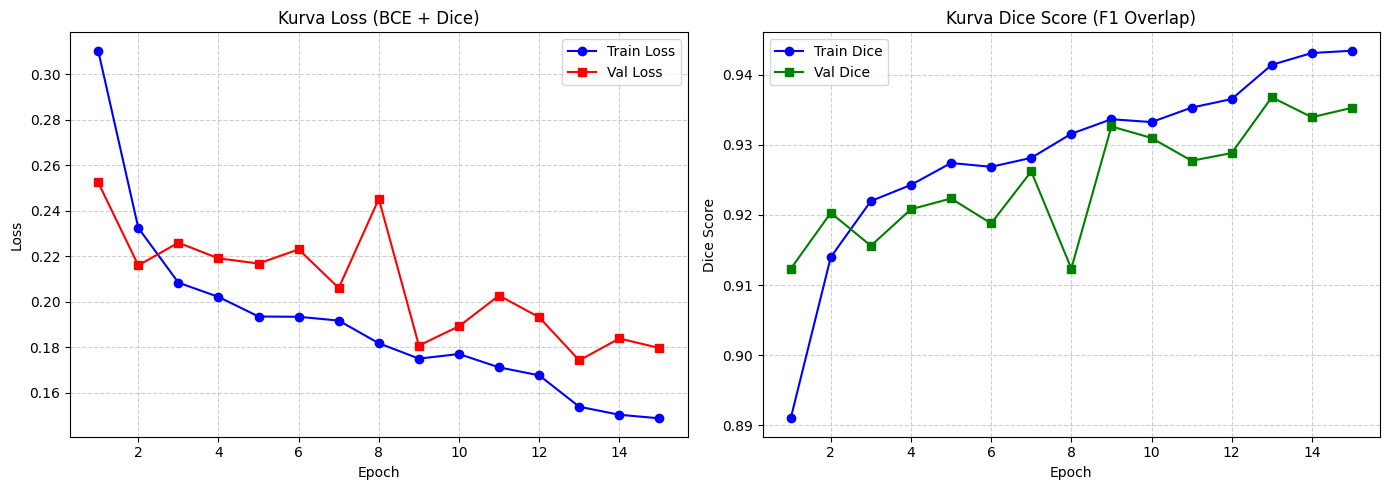

Grafik kurva tersimpan di: /content/drive/MyDrive/riset_kulit_segmentasi/unet_training_curves.png


In [10]:
# 9. Visualisasi kurva pelatihan & penyimpanan CSV ke Google Drive
df_history = pd.DataFrame(history)
csv_history_path = OUTPUT_DIR / 'unet_training_history.csv'
df_history.to_csv(csv_history_path, index=False)
print(f"Log riwayat tersimpan di: {csv_history_path}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(df_history['epoch'], df_history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(df_history['epoch'], df_history['val_loss'], 'r-s', label='Val Loss')
axes[0].set_title('Kurva Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Plot Dice Score
axes[1].plot(df_history['epoch'], df_history['train_dice'], 'b-o', label='Train Dice')
axes[1].plot(df_history['epoch'], df_history['val_dice'], 'g-s', label='Val Dice')
axes[1].set_title('Kurva Dice Score (F1 Overlap)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plot_path = OUTPUT_DIR / 'unet_training_curves.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"Grafik kurva tersimpan di: {plot_path}")

/tmp/ipykernel_5155/3434607737.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


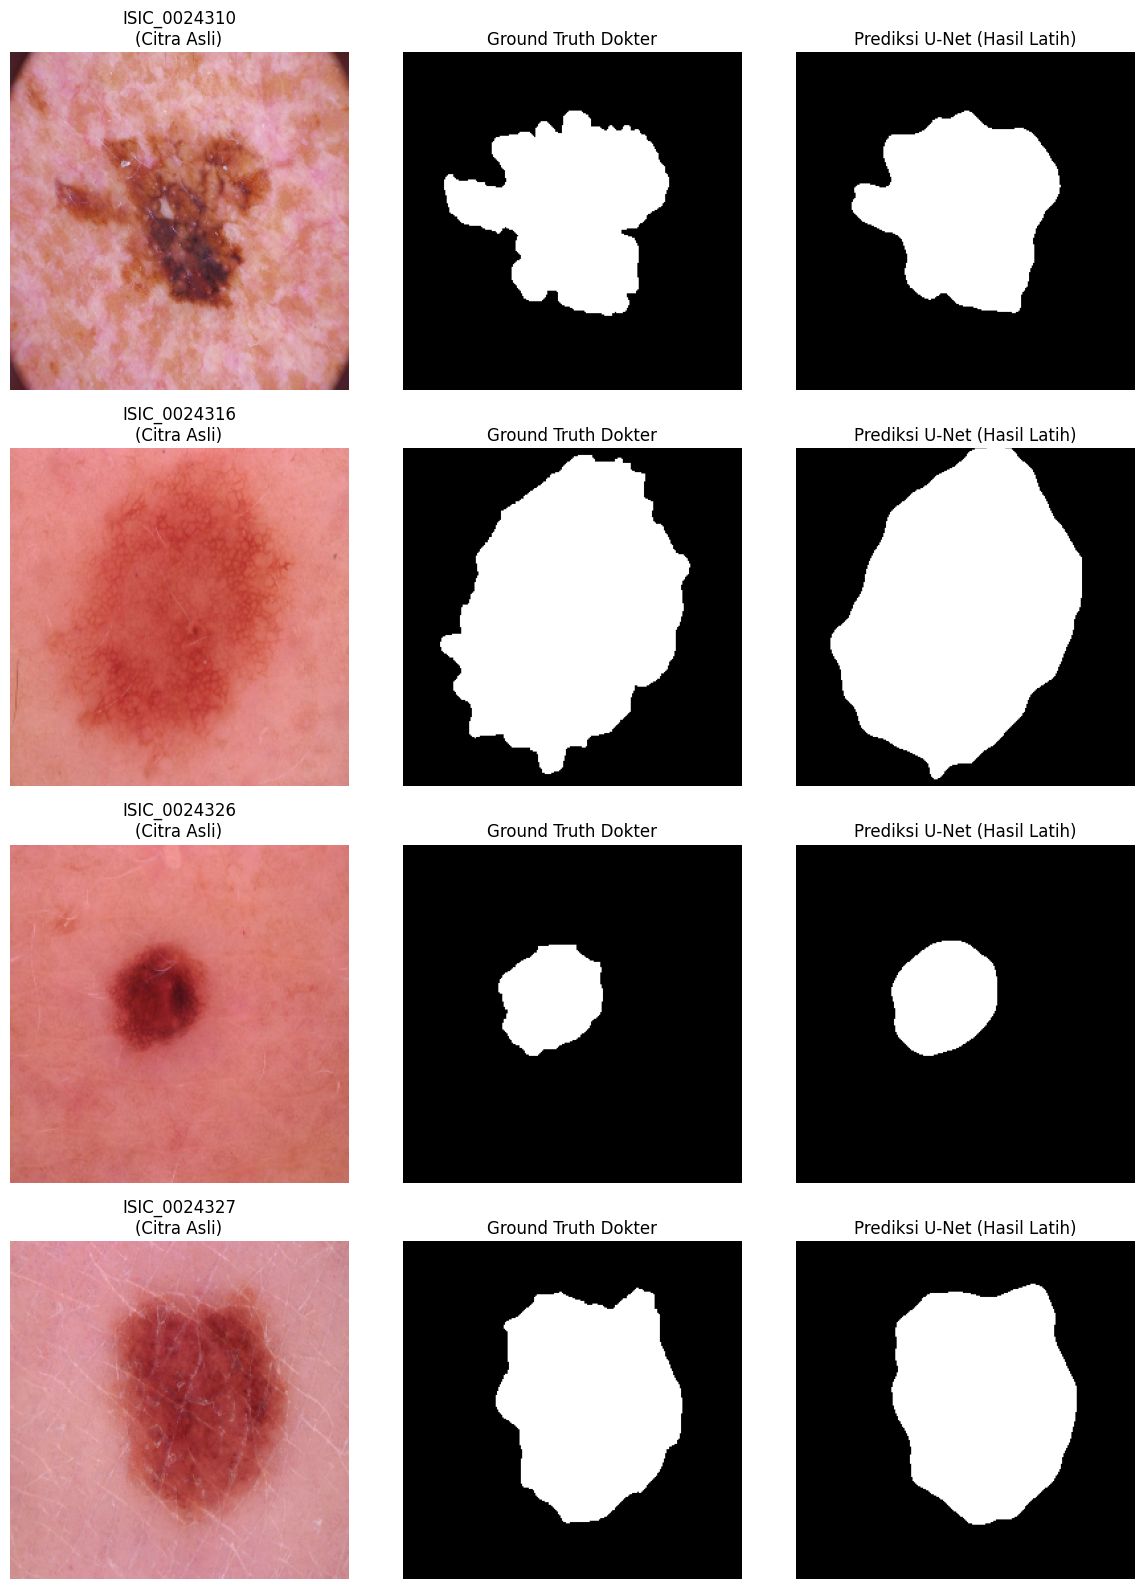

Sampel visualisasi tersimpan di: /content/drive/MyDrive/riset_kulit_segmentasi/unet_sample_predictions.png


In [11]:
# 10. Visualisasi komparasi masker: Citra Asli vs Ground Truth vs Prediksi U-Net
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

val_imgs, val_masks, val_ids = next(iter(val_loader))
val_imgs = val_imgs.to(device)

with torch.no_grad():
    with autocast():
        preds = model(val_imgs)
        preds = (torch.sigmoid(preds) > 0.5).float().cpu().numpy()

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    img_np = val_imgs[i].permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)
    gt_np = val_masks[i, 0].cpu().numpy()
    pred_np = preds[i, 0]

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"{val_ids[i]}\n(Citra Asli)")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt_np, cmap='gray')
    axes[i, 1].set_title("Ground Truth Dokter")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_np, cmap='gray')
    axes[i, 2].set_title("Prediksi U-Net (Hasil Latih)")
    axes[i, 2].axis('off')

pred_plot_path = OUTPUT_DIR / 'unet_sample_predictions.png'
plt.tight_layout()
plt.savefig(pred_plot_path, dpi=300)
plt.show()
print(f"Sampel visualisasi tersimpan di: {pred_plot_path}")

# **Fase 3**

Device aktif           : cuda (NVIDIA A100-SXM4-40GB)
Bobot Model U-Net      : /content/drive/MyDrive/riset_kulit_segmentasi/best_unet_ham10k.pth

[1/5] Mengunduh dataset citra ISIC 2019...
Using Colab cache for faster access to the 'dataset-riset-isic-2019' dataset.
Total citra ISIC 2019 ditemukan: 33,569 citra

[2/5] Memuat model U-Net ResNet-34...
Model U-Net sukses dimuat dalam mode evaluasi (eval).

[3/5] Menjalankan inferensi masker untuk 33,569 citra...


Generating Masks: 100%|██████████| 525/525 [07:12<00:00,  1.21it/s]


Seluruh masker berhasil dibuat di: /content/isic2019_pseudo_masks

[4/5] Mengompres seluruh masker ke ZIP di Google Drive...
File ZIP berhasil disimpan di Google Drive: /content/drive/MyDrive/riset_kulit_segmentasi/isic2019_pseudo_masks.zip
Ukuran ZIP: 32.61 MB

[5/5] Membuat visualisasi kontrol kualitas...


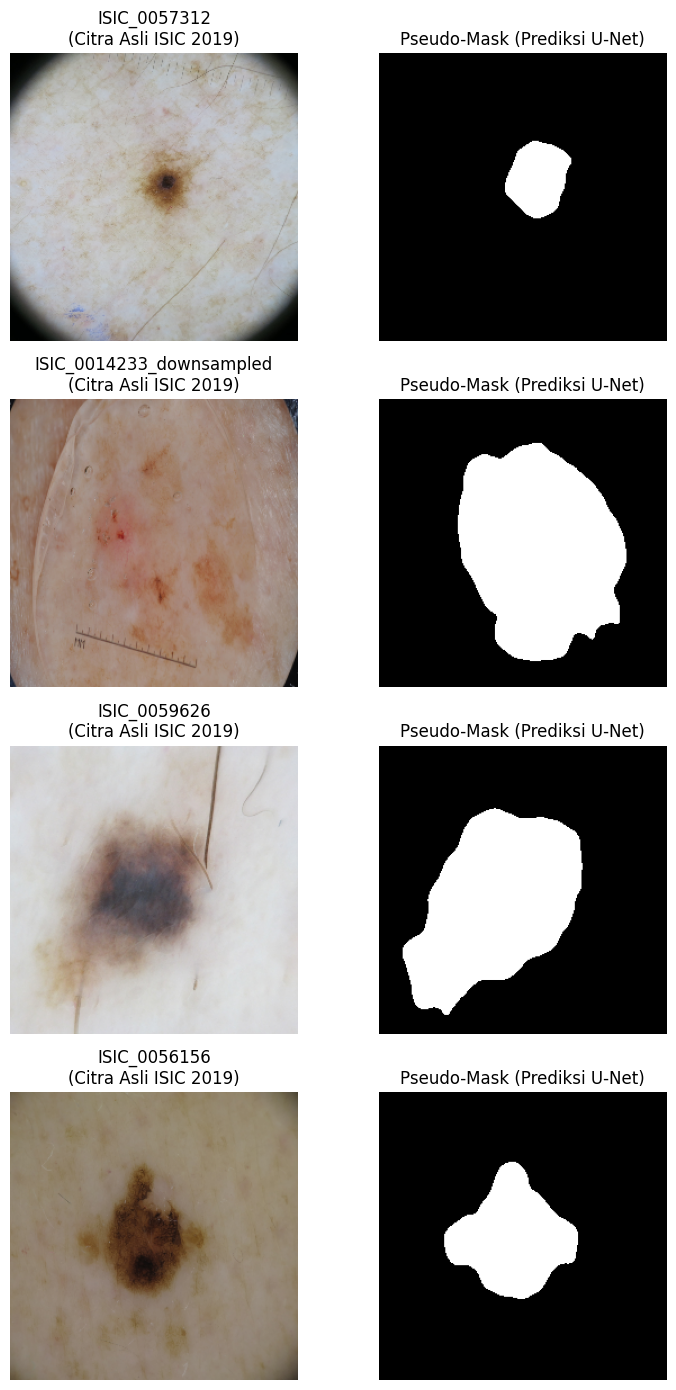

Sampel visualisasi tersimpan di: /content/drive/MyDrive/riset_kulit_segmentasi/isic2019_sample_pseudo_masks.png

=== SEMUA TAHAP FASE 3 SELESAI TUNTAS! ===


In [4]:
# ==============================================================================
# FASE 3: GENERATE PSEUDO-MASKS UNTUK ISIC 2019 MENGGUNAKAN U-NET TERLATIH
# ==============================================================================
import os
import cv2
import zipfile
import kagglehub
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# 1. Pastikan Device & Folder Siap
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = Path('/content/drive/MyDrive/riset_kulit_segmentasi')
MODEL_WEIGHTS = OUTPUT_DIR / 'best_unet_ham10k.pth'
LOCAL_MASK_DIR = Path('/content/isic2019_pseudo_masks')
LOCAL_MASK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device aktif           : {device} ({torch.cuda.get_device_name(0)})")
print(f"Bobot Model U-Net      : {MODEL_WEIGHTS}")
assert MODEL_WEIGHTS.exists(), "File bobot best_unet_ham10k.pth tidak ditemukan di Google Drive!"

# 2. Unduh Dataset Citra ISIC 2019 via KaggleHub
print("\n[1/5] Mengunduh dataset citra ISIC 2019...")
path_isic2019 = kagglehub.dataset_download("nadiraanindita/dataset-riset-isic-2019")
DIR_ISIC2019 = Path(path_isic2019)

# Kumpulkan seluruh file citra (.jpg)
isic_images = list(DIR_ISIC2019.glob('**/*.jpg'))
print(f"Total citra ISIC 2019 ditemukan: {len(isic_images):,} citra")

# 3. Pemuatan Model U-Net Terlatih
print("\n[2/5] Memuat model U-Net ResNet-34...")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
).to(device)

model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
model.eval()
print("Model U-Net sukses dimuat dalam mode evaluasi (eval).")

# 4. Dataset & DataLoader Cepat (Batch Size 64 untuk A100)
IMG_SIZE = 256
BATCH_SIZE = 64

infer_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class ISICInferenceDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        return img, path.stem

infer_ds = ISICInferenceDataset(isic_images, transform=infer_transforms)
infer_loader = DataLoader(infer_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# 5. Batch Inference dengan GPU A100
print(f"\n[3/5] Menjalankan inferensi masker untuk {len(isic_images):,} citra...")
sample_previews = []

with torch.no_grad():
    for imgs, stems in tqdm(infer_loader, desc="Generating Masks"):
        imgs = imgs.to(device)

        with autocast('cuda'):
            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).byte().cpu().numpy()[:, 0]  # Array (B, 256, 256)

        for i in range(len(stems)):
            stem = stems[i]
            mask_bin = preds[i] * 255  # Konversi ke 0 (hitam) dan 255 (putih)

            # Simpan ke folder lokal SSD Colab
            mask_filename = f"{stem}_segmentation.png"
            cv2.imwrite(str(LOCAL_MASK_DIR / mask_filename), mask_bin)

            # Simpan 4 sampel pertama untuk kontrol visual
            if len(sample_previews) < 4:
                sample_previews.append((isic_images[len(sample_previews)], mask_bin, stem))

print(f"Seluruh masker berhasil dibuat di: {LOCAL_MASK_DIR}")

# 6. Kompres ke ZIP dan Simpan Langsung ke Google Drive
print("\n[4/5] Mengompres seluruh masker ke ZIP di Google Drive...")
zip_target = OUTPUT_DIR / 'isic2019_pseudo_masks.zip'

with zipfile.ZipFile(zip_target, 'w', compression=zipfile.ZIP_DEFLATED) as zipf:
    for mask_path in LOCAL_MASK_DIR.glob('*.png'):
        zipf.write(mask_path, arcname=mask_path.name)

print(f"File ZIP berhasil disimpan di Google Drive: {zip_target}")
print(f"Ukuran ZIP: {zip_target.stat().st_size / (1024**2):.2f} MB")

# 7. Visualisasi Sampel Kontrol Kualitas
print("\n[5/5] Membuat visualisasi kontrol kualitas...")
fig, axes = plt.subplots(4, 2, figsize=(8, 14))

for i, (orig_path, mask_data, stem) in enumerate(sample_previews):
    orig_img = cv2.imread(str(orig_path))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE))

    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"{stem}\n(Citra Asli ISIC 2019)")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_data, cmap='gray')
    axes[i, 1].set_title("Pseudo-Mask (Prediksi U-Net)")
    axes[i, 1].axis('off')

plt.tight_layout()
preview_save_path = OUTPUT_DIR / 'isic2019_sample_pseudo_masks.png'
plt.savefig(preview_save_path, dpi=300)
plt.show()
print(f"Sampel visualisasi tersimpan di: {preview_save_path}")
print("\n=== SEMUA TAHAP FASE 3 SELESAI TUNTAS! ===")

In [5]:
from google.colab import runtime
runtime.unassign()